<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/07_Matrix_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Matrix Applications

**Referensi:** Practical Linear Algebra for Data Science (Mike X Cohen)

***

## Ringkasan Chapter

Setelah memahami mekanika dasar operasi matriks pada bab sebelumnya, bab ini akan menunjukkan bagaimana abstraksi aljabar linear tersebut diterjemahkan menjadi aplikasi dunia nyata dalam ilmu data. Matriks bukan sekadar tabel angka, melainkan alat komputasi untuk transformasi ruang dan penemuan pola statistik.

Bab ini berfokus pada dua pilar utama aplikasi matriks: perhitungan statistik multivariat (seperti kovarians dan korelasi yang dihitung murni menggunakan operasi perkalian matriks) dan transformasi geometris linear yang menjadi dasar dari manipulasi data grafis serta proyeksi spasial.

### Topik yang Dibahas:
1. Mean Centering Data
2. Matriks Kovarians
3. Matriks Korelasi
4. Transformasi Geometris Linear (Rotasi, Skala, Geser)


***
## Setup: Import Library

Kita memuat pustaka komputasi numerik dasar. Dalam aljabar linear, NumPy adalah pustaka utama yang paling krusial karena ia mengoptimalkan operasi matriks tingkat rendah menggunakan bahasa C.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Modul aljabar linear dan visualisasi berhasil dimuat.")


Modul aljabar linear dan visualisasi berhasil dimuat.


***
## 1. Representasi Data Multivariat dan Mean Centering

### Penjelasan Teori

Dalam ilmu data, sebuah dataset tabular sering direpresentasikan sebagai matriks desain X. Baris merepresentasikan observasi atau sampel, sedangkan kolom merepresentasikan fitur atau variabel.

Langkah pertama yang paling sering dilakukan dalam prapemrosesan aljabar linear (seperti sebelum melakukan Analisis Komponen Utama) adalah pemusatan rata rata (mean centering). Tujuannya adalah menggeser seluruh titik data sedemikian rupa sehingga pusat massanya (centroid) berada tepat di titik nol kordinat. Secara matematis, kita menghitung nilai rata rata dari setiap kolom, lalu mengurangkan nilai rata rata tersebut dari setiap elemen di dalam kolom yang bersesuaian.

In [2]:
# Simulasi Data: 3 Fitur Numerik (Kolom) dan 100 Observasi (Baris)
np.random.seed(42)
n_observasi = 100
fitur_1 = np.random.normal(50, 10, n_observasi)
fitur_2 = fitur_1 * 0.5 + np.random.normal(20, 5, n_observasi)
fitur_3 = np.random.uniform(0, 100, n_observasi)

# Membentuk Matriks Data X berukuran 100 x 3
X_data = np.column_stack((fitur_1, fitur_2, fitur_3))

# Menghitung rata rata setiap kolom (axis=0)
rata_rata_kolom = np.mean(X_data, axis=0)

# Melakukan Mean Centering menggunakan konsep Broadcasting pada NumPy
X_centered = X_data - rata_rata_kolom

print("Rata rata fitur sebelum pemusatan:", np.round(np.mean(X_data, axis=0), 2))
print("Rata rata fitur setelah pemusatan (seharusnya mendekati nol):", np.round(np.mean(X_centered, axis=0), 2))


Rata rata fitur sebelum pemusatan: [48.96 44.59 48.73]
Rata rata fitur setelah pemusatan (seharusnya mendekati nol): [0. 0. 0.]


***
## 2. Matriks Kovarians dan Formulasi Aljabar Linear

### Penjelasan Teori

Kovarians mengukur seberapa jauh dua variabel berubah secara bersama sama. Jika kovarians bernilai positif, kedua variabel cenderung bergerak ke arah yang sama. Jika negatif, mereka bergerak ke arah berlawanan.

Kekuatan utama dari aljabar linear adalah kita dapat menghitung kovarians dari ribuan variabel sekaligus tanpa menulis perulangan (loop). Rumus untuk matriks kovarians (C) adalah mengalikan matriks transpose yang sudah di mean centering dengan matriks aslinya, lalu membaginya dengan parameter skalar jumlah sampel dikurangi satu.

Rumus: C = (X_centered.T @ X_centered) / (n - 1)

Matriks Kovarians (Dihitung Menggunakan Formulasi Aljabar):
 [[ 82.48  35.33  -7.59]
 [ 35.33  37.45  10.47]
 [ -7.59  10.47 757.37]]

Matriks Kovarians (Diambil Dari Pustaka NumPy):
 [[ 82.48  35.33  -7.59]
 [ 35.33  37.45  10.47]
 [ -7.59  10.47 757.37]]


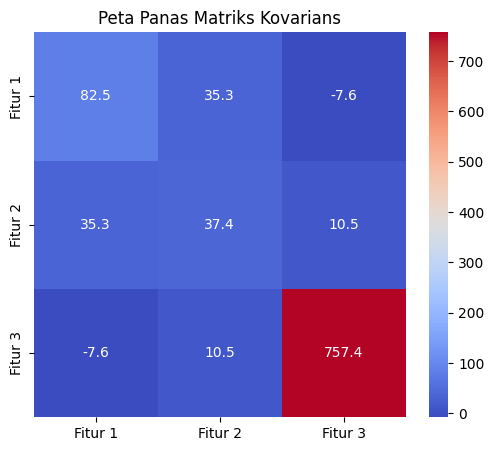

In [3]:
# Menghitung Matriks Kovarians murni menggunakan perkalian matriks
n = X_data.shape[0]
matriks_kovarians = (X_centered.T @ X_centered) / (n - 1)

print("Matriks Kovarians (Dihitung Menggunakan Formulasi Aljabar):\n", np.round(matriks_kovarians, 2))

# Memverifikasi hasil dengan fungsi bawaan NumPy
# Perhatikan bahwa rowvar=False menandakan bahwa kolom adalah variabel
kovarians_numpy = np.cov(X_data, rowvar=False)
print("\nMatriks Kovarians (Diambil Dari Pustaka NumPy):\n", np.round(kovarians_numpy, 2))

plt.figure(figsize=(6, 5))
sns.heatmap(matriks_kovarians, annot=True, fmt=".1f", cmap='coolwarm',
            xticklabels=['Fitur 1', 'Fitur 2', 'Fitur 3'], yticklabels=['Fitur 1', 'Fitur 2', 'Fitur 3'])
plt.title('Peta Panas Matriks Kovarians')
plt.show()


***
## 3. Matriks Korelasi (Pearson Correlation)

### Penjelasan Teori

Masalah utama dari kovarians adalah nilainya sangat bergantung pada skala unit metrik asli (misalnya jarak dalam meter dan berat dalam gram akan menghasilkan angka kovarians yang sangat masif). Korelasi memecahkan masalah ini dengan melakukan normalisasi pada kovarians, sehingga nilainya selalu terjebak dalam batas mutlak negatif satu hingga positif satu.

Dalam aljabar linear, kita dapat mengubah matriks kovarians menjadi matriks korelasi dengan mengalikan matriks kovarians menggunakan matriks diagonal di kedua sisinya. Matriks diagonal tersebut berisi kebalikan dari standar deviasi. Angka yang muncul di diagonal utama matriks korelasi akan selalu bernilai persis satu karena sebuah fitur selalu berkorelasi sempurna dengan dirinya sendiri.

Matriks Korelasi (Dihitung Manual):
 [[ 1.     0.636 -0.03 ]
 [ 0.636  1.     0.062]
 [-0.03   0.062  1.   ]]


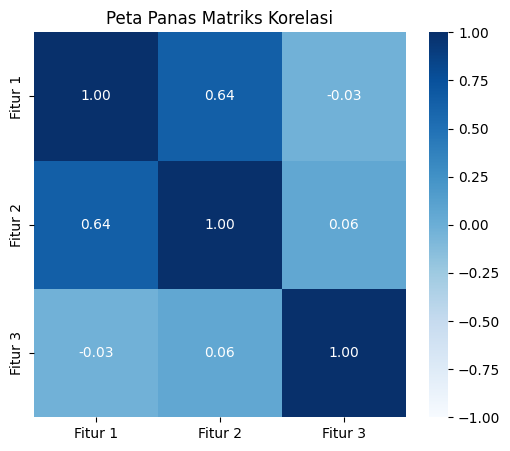

In [4]:
# Ekstraksi standar deviasi (akar dari diagonal matriks kovarians)
std_dev = np.sqrt(np.diag(matriks_kovarians))

# Membuat matriks diagonal yang berisi nilai kebalikan dari standar deviasi
matriks_std_inv = np.diag(1.0 / std_dev)

# Mengalikan matriks untuk mendapatkan Korelasi: R = D_inv @ C @ D_inv
matriks_korelasi = matriks_std_inv @ matriks_kovarians @ matriks_std_inv

print("Matriks Korelasi (Dihitung Manual):\n", np.round(matriks_korelasi, 3))

plt.figure(figsize=(6, 5))
sns.heatmap(matriks_korelasi, annot=True, fmt=".2f", cmap='Blues', vmin=-1, vmax=1,
            xticklabels=['Fitur 1', 'Fitur 2', 'Fitur 3'], yticklabels=['Fitur 1', 'Fitur 2', 'Fitur 3'])
plt.title('Peta Panas Matriks Korelasi')
plt.show()


***
## 4. Transformasi Geometris Linear

### Penjelasan Teori

Setiap matriks pada dasarnya adalah kumpulan setruksi untuk memodifikasi ruang. Jika kita menganggap barisan data sebagai titik titik kordinat geometris, kita dapat mengalikan seluruh titik data tersebut sekaligus dengan matriks transformasi untuk menggeser, memutar, memantulkan, atau merentangkannya.

Ini adalah konsep paling mendasar di balik grafika komputer dua dimensi dan pemrosesan manipulasi citra.

Beberapa matriks dua dimensi yang menjadi standar meliputi:
* Matriks Skala: Memiliki angka pada diagonal utama untuk merentangkan sumbu tertentu.
* Matriks Geser (Shear Matrix): Mendorong titik secara asimetris searah sumbu horizontal atau vertikal.
* Matriks Rotasi: Memutar titik sebesar sudut tertentu menggunakan fungsi trigonometri sinus dan kosinus.

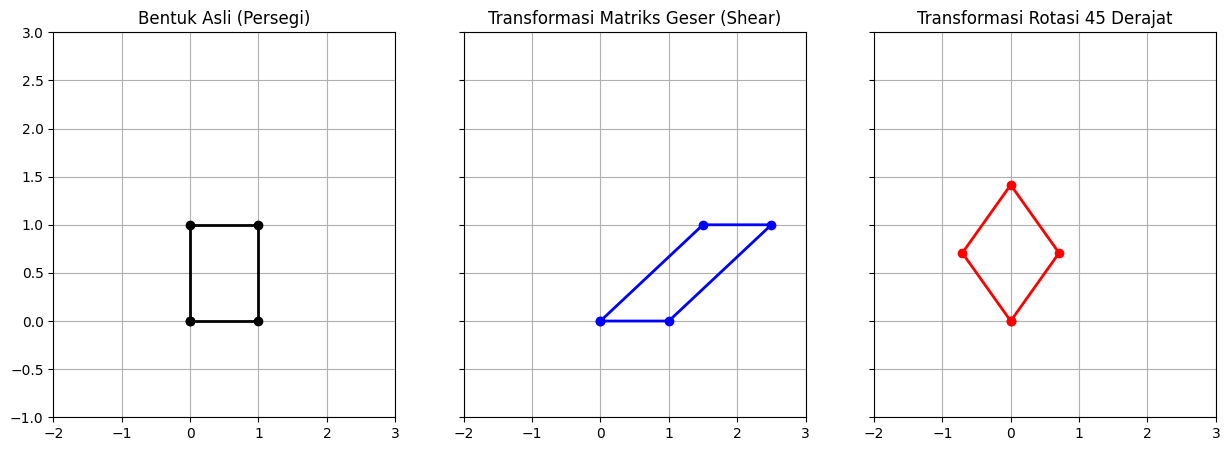

In [5]:
# Membuat dataset titik kordinat yang membentuk pola objek persegi
x_titik = [0, 1, 1, 0, 0]
y_titik = [0, 0, 1, 1, 0]
# Menyusun kordinat ke dalam format matriks di mana setiap kolom adalah [x, y]
titik_awal = np.vstack((x_titik, y_titik))

# 1. Definisi Matriks Geser (Shear) pada sumbu X
faktor_geser = 1.5
matriks_shear = np.array([
    [1, faktor_geser],
    [0, 1]
])

# 2. Definisi Matriks Rotasi (Memutar 45 derajat berlawanan arah jarum jam)
sudut = np.pi / 4
matriks_rotasi = np.array([
    [np.cos(sudut), -np.sin(sudut)],
    [np.sin(sudut), np.cos(sudut)]
])

# Melakukan Transformasi dengan Perkalian Titik Matriks (T @ P)
titik_shear = matriks_shear @ titik_awal
titik_rotasi = matriks_rotasi @ titik_awal

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

axes[0].plot(titik_awal[0, :], titik_awal[1, :], color='black', linewidth=2, marker='o')
axes[0].set_title('Bentuk Asli (Persegi)')
axes[0].grid(True)
axes[0].set_xlim(-2, 3)
axes[0].set_ylim(-1, 3)

axes[1].plot(titik_shear[0, :], titik_shear[1, :], color='blue', linewidth=2, marker='o')
axes[1].set_title('Transformasi Matriks Geser (Shear)')
axes[1].grid(True)

axes[2].plot(titik_rotasi[0, :], titik_rotasi[1, :], color='red', linewidth=2, marker='o')
axes[2].set_title('Transformasi Rotasi 45 Derajat')
axes[2].grid(True)

plt.show()
